In [3]:
import sys
sys.path.insert(0, 'C:/Users/pale4/projects/factor-research-platform')

from config.settings import engine
from factors.momentum import Momentum

mom = Momentum("momentum", engine)
raw = mom.compute()
print(raw.head(20))
print(raw.dropna().shape)

                         date ticker  raw_score
0   2021-02-01 00:00:00-06:00      A        NaN
1   2021-03-01 00:00:00-06:00      A        NaN
2   2021-04-01 00:00:00-06:00      A        NaN
3   2021-05-01 00:00:00-05:00      A        NaN
4   2021-06-01 00:00:00-05:00      A        NaN
5   2021-07-01 00:00:00-05:00      A        NaN
6   2021-08-01 00:00:00-05:00      A        NaN
7   2021-09-01 00:00:00-05:00      A        NaN
8   2021-10-01 00:00:00-05:00      A        NaN
9   2021-11-01 00:00:00-06:00      A        NaN
10  2021-12-01 00:00:00-06:00      A        NaN
11  2022-01-01 00:00:00-06:00      A   0.337190
12  2022-02-01 00:00:00-06:00      A   0.190550
13  2022-03-01 00:00:00-06:00      A   0.077452
14  2022-04-01 00:00:00-06:00      A   0.031033
15  2022-05-01 00:00:00-05:00      A  -0.113536
16  2022-06-01 00:00:00-05:00      A  -0.122185
17  2022-07-01 00:00:00-05:00      A  -0.184135
18  2022-08-01 00:00:00-05:00      A  -0.199390
19  2022-09-01 00:00:00-05:00      A  -0

In [4]:
normalized = mom.normalize(raw.dropna())
print(normalized.head())

with_quintiles = mom.assign_quintiles(normalized)
print(with_quintiles.head())

                         date ticker  raw_score   z_score
11  2022-01-01 00:00:00-06:00      A   0.337190  0.586653
12  2022-02-01 00:00:00-06:00      A   0.190550  0.266591
13  2022-03-01 00:00:00-06:00      A   0.077452  0.011836
14  2022-04-01 00:00:00-06:00      A   0.031033 -0.240554
15  2022-05-01 00:00:00-05:00      A  -0.113536 -0.504126
                         date ticker  raw_score   z_score quintile
11  2022-01-01 00:00:00-06:00      A   0.337190  0.586653        4
12  2022-02-01 00:00:00-06:00      A   0.190550  0.266591        3
13  2022-03-01 00:00:00-06:00      A   0.077452  0.011836        3
14  2022-04-01 00:00:00-06:00      A   0.031033 -0.240554        3
15  2022-05-01 00:00:00-05:00      A  -0.113536 -0.504126        2


In [8]:
derived_df = pd.read_sql("SELECT * FROM derived_fundamentals", engine)
monthly_df = pd.read_sql("SELECT * FROM monthly_returns", engine)

In [11]:
print(monthly_df['month_start'].dtype)
print(derived_df['report_date'].dtype)

object
object


In [4]:
import sys
sys.path.insert(0, 'C:/Users/pale4/projects/factor-research-platform')

from config.settings import engine
from factors.size import Size
from factors.value import Value

size = Size("size", engine)
val = Value("value", engine)

size_raw = size.compute()
value_raw = val.compute()

print(size_raw.dropna().shape)
print(value_raw.dropna().shape)
print(value_raw.dropna().head(20))

(7661, 3)
(7661, 3)
            date ticker    raw_score
20653 2024-07-01   EXPD     0.126284
20860 2024-07-01  BRK-B  1029.513437
20973 2024-08-01   EXPD     0.126284
21181 2024-08-01  BRK-B  1029.513437
21372 2024-09-01  BRK-B  1029.513437
21840 2024-09-01   EXPD     0.126284
21869 2024-10-01   VTRS     1.514565
21871 2024-10-01    CNP     0.569583
21872 2024-10-01  BRK-B   950.724247
21878 2024-10-01   TRMB     0.384957
21880 2024-10-01   DASH     0.127734
21883 2024-10-01   SCHW     0.405818
21884 2024-10-01   FSLR     0.284359
21888 2024-10-01    WRB     0.403925
21890 2024-10-01    APP     0.021422
21892 2024-10-01     IP     0.533546
21894 2024-10-01    AVY     0.138281
21897 2024-10-01   IBKR     0.275007
21900 2024-10-01    WTW     0.255736
21903 2024-10-01   DDOG     0.067351


In [10]:
print(derived_df[derived_df['ticker'] == 'BRK-B'][['ticker', 'report_date', 'stockholders_equity', 'market_cap']])

    ticker report_date  stockholders_equity    market_cap
335  BRK-B  2024-06-30         6.016970e+11  5.844479e+08
336  BRK-B  2024-09-30         6.290690e+11  6.616735e+08
337  BRK-B  2024-12-31         6.493680e+11  6.519177e+08
338  BRK-B  2025-03-31         6.544710e+11  7.659688e+08
339  BRK-B  2025-06-30         6.679890e+11  6.986456e+08


In [11]:
print(derived_df[derived_df['ticker'] == 'BRK-B'][['ticker', 'report_date', 'ordinary_shares_number']])

    ticker report_date  ordinary_shares_number
335  BRK-B  2024-06-30               1436696.0
336  BRK-B  2024-09-30               1437608.0
337  BRK-B  2024-12-31               1438223.0
338  BRK-B  2025-03-31               1438223.0
339  BRK-B  2025-06-30               1438223.0


In [12]:
print(derived_df[derived_df['ticker'] == 'AAPL'][['ticker', 'report_date', 'ordinary_shares_number', 'market_cap']])

  ticker report_date  ordinary_shares_number    market_cap
5   AAPL  2024-12-31            1.503787e+10  3.745325e+12
6   AAPL  2025-03-31            1.493932e+10  3.304070e+12
7   AAPL  2025-06-30            1.485672e+10  3.038905e+12
8   AAPL  2025-09-30            1.477326e+10  3.754559e+12
9   AAPL  2025-12-31            1.469793e+10  3.992042e+12


In [1]:
import sys
sys.path.insert(0, 'C:/Users/pale4/projects/factor-research-platform')

from config.settings import engine
from factors.volatility import Volatility
from factors.quality import Quality
from factors.size import Size
from factors.value import Value
from factors.momentum import Momentum

In [35]:
mom = Momentum('momentum', engine)

raw_mom = mom.compute()
mom_norm = mom.normalize(raw_mom.dropna())
mom_q = mom.assign_quintiles(mom_norm)
mom.store(mom_q)

In [36]:
qua = Quality('quality', engine)

raw_qua = qua.compute()
qua_norm = qua.normalize(raw_qua.dropna())
qua_q = qua.assign_quintiles(qua_norm)
qua.store(qua_q)

In [37]:
size = Size('size', engine)

raw_size = size.compute()
size_norm = size.normalize(raw_size.dropna())
size_q = size.assign_quintiles(size_norm)
size.store(size_q)

In [38]:
value = Value('value', engine)

raw_value = value.compute()
value_norm = value.normalize(raw_value.dropna())
value_q = value.assign_quintiles(value_norm)
value.store(value_q)

In [2]:
vol = Volatility("volatility", engine)
vol_raw = vol.compute()
print(vol_raw['date'].head(10))

0     2021-02-01
23    2021-03-01
44    2021-04-01
64    2021-05-01
86    2021-06-01
107   2021-07-01
129   2021-08-01
150   2021-09-01
171   2021-10-01
192   2021-11-01
Name: date, dtype: datetime64[us]


In [3]:
vol_norm = vol.normalize(vol_raw.dropna())
vol_q = vol.assign_quintiles(vol_norm)
vol.store(vol_q)

In [63]:
vol = Volatility('volatility', engine)

raw_vol = vol.compute()
vol_norm = vol.normalize(raw_vol.dropna())
vol_q = vol.assign_quintiles(vol_norm)
vol.store(vol_q)

In [64]:
print(raw_vol['date'].head(10))

0     2021-02-26
23    2021-03-31
44    2021-04-30
64    2021-05-28
86    2021-06-30
107   2021-07-30
129   2021-08-31
150   2021-09-30
171   2021-10-29
192   2021-11-30
Name: date, dtype: datetime64[s]


factor_name  momentum  quality  size  value  volatility
factor_name                                            
momentum           49       20    20     20          49
quality            20       20    20     20          20
size               20       20    20     20          20
value              20       20    20     20          20
volatility         49       20    20     20          49


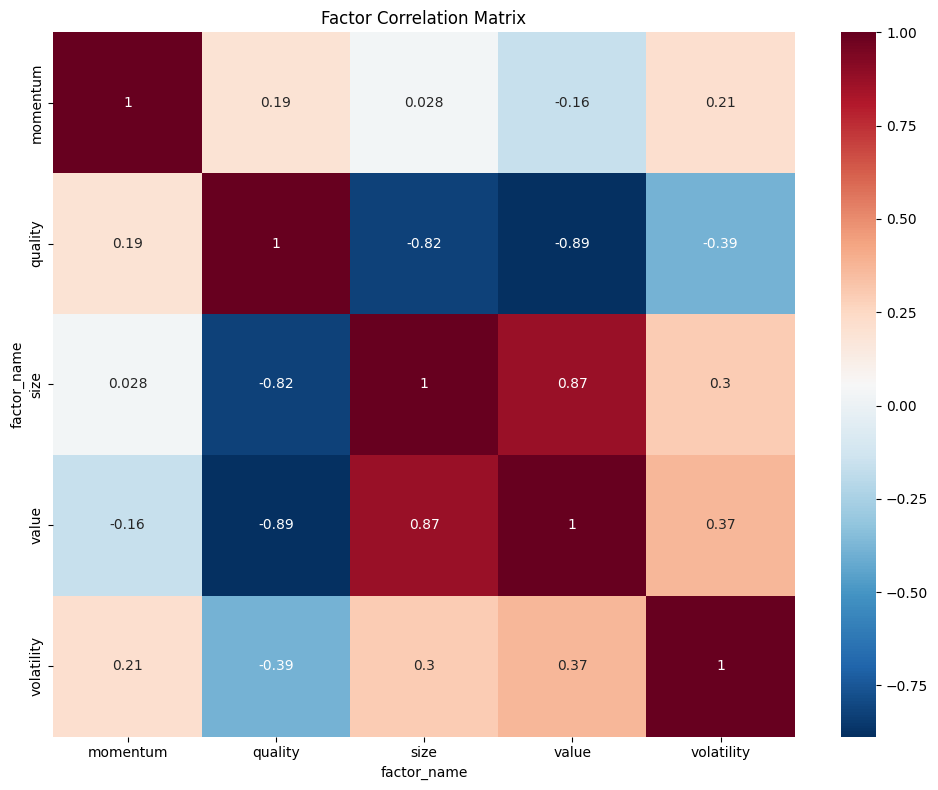

In [3]:
import sys
sys.path.insert(0, 'C:/Users/pale4/projects/factor-research-platform')

from analysis.correlation_analysis import compute_factor_correlations, plot_correlation_heatmap
from config.settings import engine

corr, overlap = compute_factor_correlations(engine)
print(overlap)
_ = plot_correlation_heatmap(corr)

In [10]:
import sys
sys.path.insert(0, 'C:/Users/pale4/projects/factor-research-platform')

import pandas as pd
from scipy.stats import spearmanr
from config.settings import engine

df_fs = pd.read_sql('SELECT * FROM factor_scores', engine)

df_fr = pd.read_sql('SELECT * FROM forward_returns', engine)
df_fr = df_fr.rename(columns = {'month_start': 'date'})

df = pd.merge(df_fs, df_fr, on = ['ticker', 'date'])

In [35]:
results = []
for (factor, date), group in df.groupby(['factor_name', 'date']):
    clean = group.dropna(subset = ['raw_score', 'next_month_return'])
    if len(clean) < 10:
        continue
    coef, p = spearmanr(clean['raw_score'], clean['next_month_return'])
    results.append({
        'factor_name': factor, 
        'date': date, 
        'ic': coef, 
        'p_value': p
    })

df_ic = pd.DataFrame(results)

In [43]:
df_ic.groupby('factor_name')['ic'].agg(['mean', 'std', 'count']).assign(ir = lambda x: x['mean'] / x['std'], hit_rate = df_ic.groupby('factor_name')['ic'].apply(lambda x: (x > 0).mean()))

,mean,std,count,ir,hit_rate
factor_name,,,,,
momentum,0.026966,0.182477,48,0.147780,0.625000
quality,-0.017012,0.070407,16,-0.241623,0.437500
size,-0.002624,0.083848,16,-0.031291,0.375000
value,0.047769,0.132125,16,0.361545,0.687500
volatility,-0.033049,0.260373,48,-0.126929,0.416667


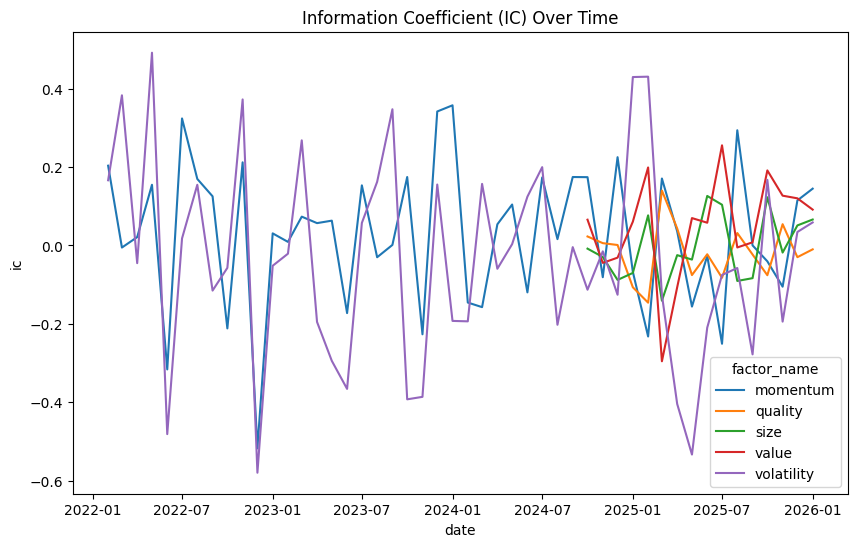

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns 

plt.figure(figsize = (10, 6))
sns.lineplot(data = df_ic, x = 'date', y = 'ic', hue = 'factor_name')
plt.title('Information Coefficient (IC) Over Time')
plt.show()

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.insert(0, 'C:/Users/pale4/projects/factor-research-platform')

import pandas as pd
import os
from config.settings import PROJECT_ROOT
from config.settings import engine

sql_path = os.path.join(PROJECT_ROOT, 'sql', 'queries', 'backtest_returns.sql')

In [2]:
backtest_query = open(sql_path).read()
df_backtest = pd.read_sql(backtest_query, engine)

In [7]:
df = df_backtest.groupby(['factor_name', 'quintile'])['avg_return'].mean().unstack()
df

quintile,1,2,3,4,5
factor_name,,,,,
momentum,0.009053,0.009930,0.010233,0.011571,0.017598
quality,0.016353,0.012720,0.011625,0.007688,0.011354
size,0.008234,0.013449,0.011743,0.012238,0.014984
value,0.007511,0.011083,0.011677,0.010239,0.019364
volatility,0.021002,0.011778,0.011579,0.007589,0.006351


In [14]:
df.reset_index()

quintile,factor_name,1,2,3,4,5
0,momentum,0.009053,0.009930,0.010233,0.011571,0.017598
1,quality,0.016353,0.012720,0.011625,0.007688,0.011354
2,size,0.008234,0.013449,0.011743,0.012238,0.014984
3,value,0.007511,0.011083,0.011677,0.010239,0.019364
4,volatility,0.021002,0.011778,0.011579,0.007589,0.006351


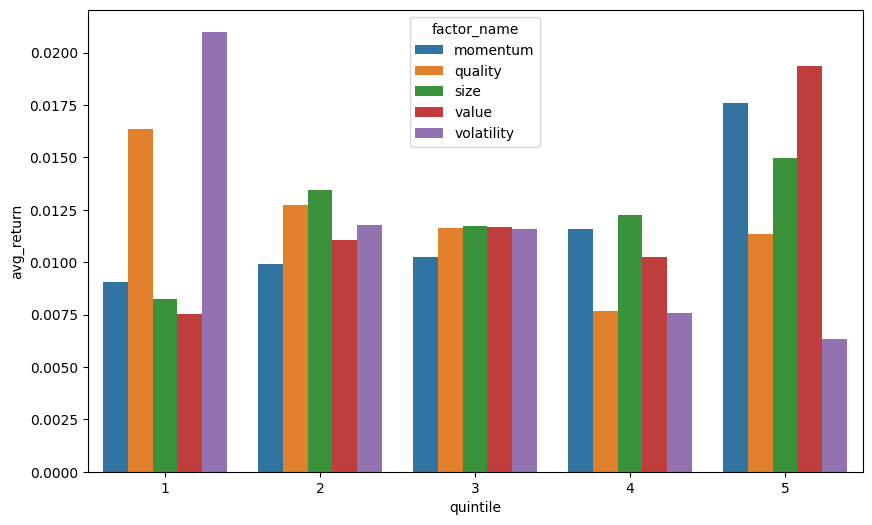

In [13]:
plt.figure(figsize = (10, 6))
sns.barplot(data = df.reset_index().melt(id_vars = 'factor_name', var_name = 'quintile', value_name = 'avg_return'), x = 'quintile', hue = 'factor_name', y = 'avg_return')
plt.show()

In [14]:
import sys
sys.path.insert(0, 'C:/Users/pale4/projects/factor-research-platform')

import os
import numpy as np
import pandas as pd
import statsmodels.api as sm
from config.settings import PROJECT_ROOT
from config.settings import engine

sql_path = os.path.join(PROJECT_ROOT, 'sql', 'queries', 'backtest_returns.sql')

In [11]:
backtest_query = open(sql_path).read()
df_backtest = pd.read_sql(backtest_query, engine)

In [17]:
results = []
for factor, group in df_backtest.groupby('factor_name'):
    returns = group['long_short'].dropna()

    if len(returns) < 12:
        continue 

    # Regression on a constant only - testing if mean return != 0
    # add_constant adds a column of 1s (the intercept)
    X = sm.add_constant(np.ones(len(returns)))

    # OLS = Ordinary Least Squares
    # cov_type = 'HAC' = Newey-West standard errors
    # maxlags = 6 = correct for up to 6 months of autocorrelation
    model = sm.OLS(returns.values, X).fit(cov_type = 'HAC', cov_kwds = {'maxlags': 6})

    results.append({
        'factor_name': factor,
        'mean_return': returns.mean(),
        'nw_tstat': model.tvalues[0],           # t-statistic with Newey-West correction
        'nw_pvalue': model.pvalues[0],          # corresponding p-value
        'n_months': len(returns),
        'significant': model.pvalues[0] < 0.05  # conventional threshold
    })

In [18]:
results

[{'factor_name': 'momentum',
  'mean_return': np.float64(0.00837133480251885),
  'nw_tstat': np.float64(1.687950999313733),
  'nw_pvalue': np.float64(0.09142063554805739),
  'n_months': 49,
  'significant': np.False_},
 {'factor_name': 'quality',
  'mean_return': np.float64(-0.004749241753401688),
  'nw_tstat': np.float64(-1.4472252216225754),
  'nw_pvalue': np.float64(0.1478338547749283),
  'n_months': 20,
  'significant': np.False_},
 {'factor_name': 'size',
  'mean_return': np.float64(0.006412468447738073),
  'nw_tstat': np.float64(1.4194891965947627),
  'nw_pvalue': np.float64(0.1557564442987378),
  'n_months': 20,
  'significant': np.False_},
 {'factor_name': 'value',
  'mean_return': np.float64(0.011260234939960534),
  'nw_tstat': np.float64(1.631364743360067),
  'nw_pvalue': np.float64(0.10281337960414011),
  'n_months': 20,
  'significant': np.False_},
 {'factor_name': 'volatility',
  'mean_return': np.float64(-0.014351600259496356),
  'nw_tstat': np.float64(-1.9891415154603056

In [19]:
from scipy.stats import false_discovery_control

In [20]:
p_values = [r['nw_pvalue'] for r in results]

# Bonferroni: multiply each p-value by the number of tests
bonferroni = [min(p * 5, 1.0) for p in p_values]

# Benjamini-Hochberg FDR
bh_adjusted = false_discovery_control(p_values, method = 'bh')

In [24]:
print(bonferroni)
print(bh_adjusted)

[np.float64(0.45710317774028697), np.float64(0.7391692738746415), np.float64(0.778782221493689), np.float64(0.5140668980207006), np.float64(0.23342792543506366)]
[0.15575644 0.15575644 0.15575644 0.15575644 0.15575644]


In [1]:
import sys
sys.path.insert(0, 'C:/Users/pale4/projects/factor-research-platform')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from config.settings import engine
from config.settings import PROJECT_ROOT

sql_path = os.path.join(PROJECT_ROOT, 'sql', 'queries', 'backtest_returns.sql')

backtest_query = open(sql_path).read()
df_backtest = pd.read_sql(backtest_query, engine)

In [11]:
returns = df_backtest.sort_values(['factor_name', 'date']).copy()

In [18]:
cumulative = (1 + returns['long_short']).groupby([returns['factor_name']]).cumprod()

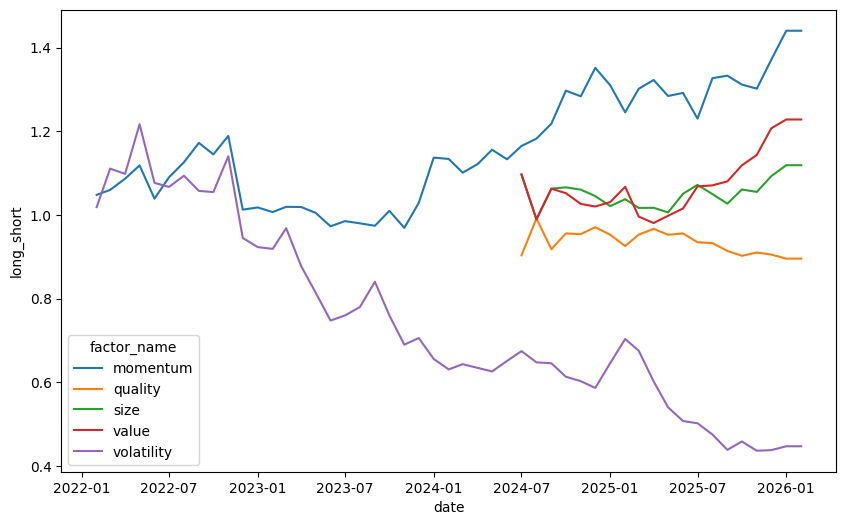

In [22]:
plt.figure(figsize = (10, 6))
sns.lineplot(x = returns['date'], y = cumulative, hue = returns['factor_name'])
plt.show()

In [7]:
from analysis.backtest import compute_performance_metrics, compute_turnover

perf_df = compute_performance_metrics(engine)

In [4]:
turnover_df = compute_turnover(engine)

In [6]:
# annual cost = monthly turnover * 12 months * 2 legs * 10bps per trade
turnover_df['annual_cost'] = turnover_df['avg_monthly_turnover'] * 12 * 2 * 0.001

In [8]:
merged = perf_df.merge(turnover_df, on = 'factor_name')
merged['adj_annual_return'] = merged['annual_return'] - merged['annual_cost']
merged['adj_sharpe'] = merged['adj_annual_return'] / (merged['annual_return'] / merged['annual_sharpe'])

In [9]:
merged

,factor_name,total_return,annual_return,annual_sharpe,max_drawdown,n_months,avg_monthly_turnover,annual_cost,adj_annual_return,adj_sharpe
0,momentum,0.440176,0.093442,0.683172,-0.184776,49,0.222240,0.005334,0.088108,0.644176
1,quality,-0.104326,-0.063970,-0.416742,-0.096720,20,0.140633,0.003375,-0.067345,-0.438730
2,size,0.118843,0.069699,0.547025,-0.097648,20,0.102593,0.002462,0.067237,0.527700
3,value,0.228091,0.131197,0.882068,-0.105700,20,0.101784,0.002443,0.128754,0.865644
4,volatility,-0.552654,-0.178811,-0.800267,-0.641094,49,0.060102,0.001442,-0.180253,-0.806723
